# SUSTAIN — Environmental Footprint of How We Feed Ourselves

**Datathon 2026 · Sustain track · EDA**

> *What is the environmental footprint of how we feed ourselves?*

Analysis logic lives in `src/` (`load`, `clean`, `footprint`, `viz`); this notebook orchestrates and narrates.

**Deliverables:** 1) Explore → find the high-impact footprint · 2) Quantify cost & levers · 3) Strategize (setup).

## 0 · Setup

In [1]:
import sys; sys.path.append('..')  # so `src` imports work from notebooks/
import pandas as pd, matplotlib.pyplot as plt
from src import load, clean, footprint, viz

# Put full normalized CSVs in ../data/raw/ (see README).
data = load.load_all()          # dict: emissions / intensities / landuse
emis, inten, land = data['emissions'], data['intensities'], data['landuse']
for name, df in data.items(): clean.basic_report(df, name)

=== emissions ===
shape: (2500090, 14)
years: 1961 -> 2050
missing Value: 0
flags:
 Flag Description
Estimated value    2432982
Official figure      45804
FAO estimate         21304
Name: count, dtype: int64

=== intensities ===
shape: (409511, 13)
years: 1961 -> 2023
missing Value: 0
flags:
 Flag Description
Estimated value                           325966
Official figure                            54961
Imputed value                              24414
Figure from international organization      4170
Name: count, dtype: int64

=== landuse ===
shape: (421948, 12)
years: 1961 -> 2025
missing Value: 0
flags:
 Flag Description
Estimated value                           209318
Imputed value                             133727
Official figure                            69594
Figure from international organization      9309
Name: count, dtype: int64



## 1 · Explore — find the high-impact footprint

In [2]:
# Drop M49 aggregates (World/regions) or they dominate every ranking.
emis_c, _ = clean.split_countries_aggregates(emis)
inten_c, _ = clean.split_countries_aggregates(inten)
land_c, _ = clean.split_countries_aggregates(land)
print('countries:', emis_c['Area'].nunique())

countries: 245


In [3]:
YEAR = clean.pick_analysis_year(emis_c)
ELEM = clean.pick_co2eq_element(emis_c)   # CO2eq total so gases compare
print('analysis year:', YEAR, '| element:', ELEM)

analysis year: 2023 | element: Emissions (CO2eq) (AR5)


### Discovery — confirm Element & Item names
Auto-selection can pick a single-gas element or an aggregate item. Check these before trusting the rankings.

In [4]:
# 1) All CO2eq elements — confirm the ALL-GAS total is selected.
print('CO2eq elements:')
for e in sorted(x for x in emis_c['Element'].unique() if 'CO2eq' in str(x)):
    print('  ', e)
print('--> selected element:', ELEM)

# 2) Scope check: which items are dropped as non-agrifood / aggregates.
raw = footprint.rank_sources(emis_c, YEAR, ELEM, agrifood_only=False, leaf_only=False).head(16)
print('\nTop items — [agg]=rollup, [non-food]=Energy/IPPU/Waste, [KEEP]=agrifood source:')
for it, v in raw.items():
    if not footprint.is_leaf_source(it):        tag='[agg]'
    elif not footprint.is_agrifood_source(it):  tag='[non-food]'
    else:                                        tag='[KEEP]'
    print(f'  {v:14.0f}  {tag:11} {it}')

CO2eq elements:
   Emissions (CO2eq) (AR5)
   Emissions (CO2eq) from CH4 (AR5)
   Emissions (CO2eq) from F-gases (AR5)
   Emissions (CO2eq) from N2O (AR5)
--> selected element: Emissions (CO2eq) (AR5)

Top items — [agg]=rollup, [non-food]=Energy/IPPU/Waste, [KEEP]=agrifood source:
        74955742  [agg]       All sectors with LULUCF
        72657503  [agg]       All sectors without LULUCF
        53737496  [non-food]  Energy
        25593833  [agg]       Agrifood systems
        18085116  [agg]       Emissions on agricultural land
        11551553  [agg]       AFOLU
        11531952  [agg]       Farm gate
         9253314  [agg]       IPCC Agriculture
         7508717  [KEEP]      Pre- and post-production
         6662456  [KEEP]      Emissions from livestock
         6553164  [KEEP]      Land-use change
         6500165  [non-food]  IPPU
         6150541  [KEEP]      Net Forest conversion
         4644648  [KEEP]      Enteric Fermentation
         2883212  [non-food]  Waste
         

> **Scope:** rankings are restricted to **agrifood** sources — economy-wide Energy, IPPU (industry) and Waste are excluded, since the track asks about the *food* footprint. **Granularity note:** FAOSTAT mixes levels in `Item` (e.g. *Emissions from livestock* partly contains *Enteric Fermentation*; *Land-use change* overlaps *Net Forest conversion*). Read them as a landscape, don't sum overlapping items as if mutually exclusive.

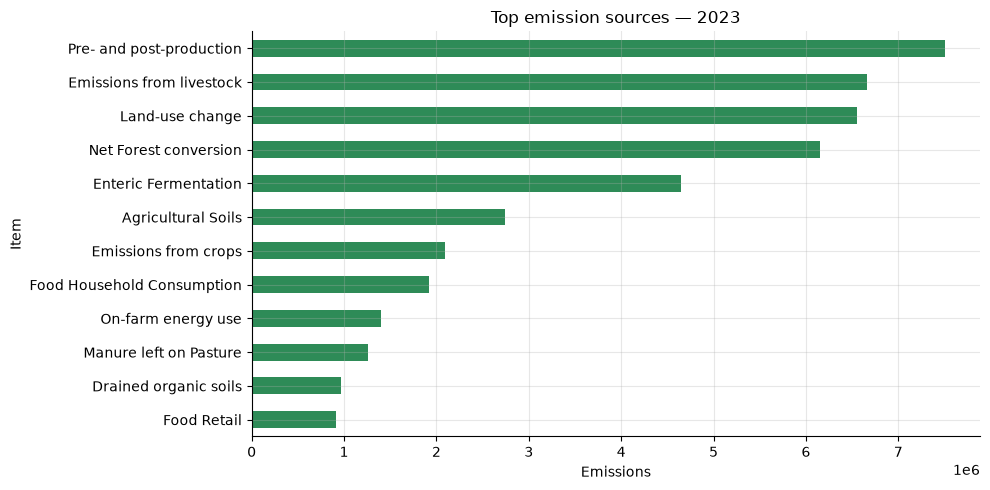

Item
Pre- and post-production      7.508717e+06
Emissions from livestock      6.662456e+06
Land-use change               6.553164e+06
Net Forest conversion         6.150541e+06
Enteric Fermentation          4.644648e+06
Agricultural Soils            2.743205e+06
Emissions from crops          2.092243e+06
Food Household Consumption    1.918880e+06
On-farm energy use            1.404337e+06
Manure left on Pasture        1.256583e+06
Drained organic soils         9.686124e+05
Food Retail                   9.132758e+05
Name: Value, dtype: float64

In [5]:
item_rank = footprint.rank_sources(emis_c, YEAR, ELEM)
viz.barh_ranking(item_rank, f'Top emission sources — {YEAR}', 'Emissions', color='seagreen'); plt.show()
item_rank.head(12)

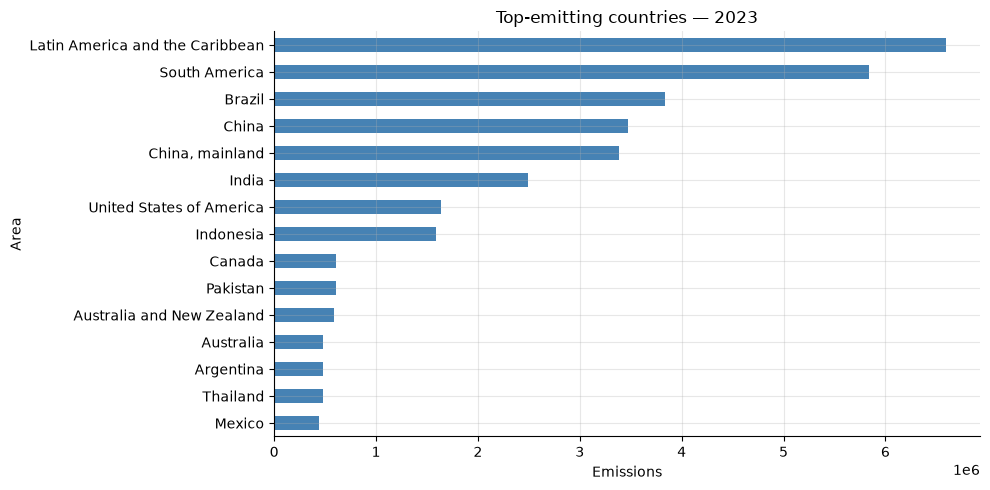

top 10 = 66.8% of ranked total


In [6]:
country_rank = footprint.rank_countries(emis_c, YEAR, ELEM)
viz.barh_ranking(country_rank, f'Top-emitting countries — {YEAR}', 'Emissions', n=15, color='steelblue'); plt.show()
print(f'top 10 = {100*country_rank.head(10).sum()/country_rank.sum():.1f}% of ranked total')

## 2 · Quantify the footprint & locate the levers

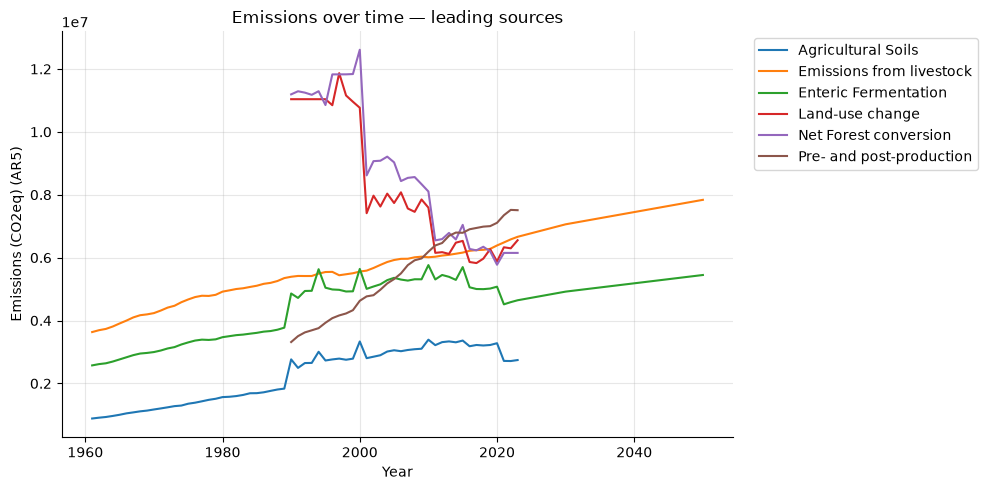

In [7]:
focus = list(item_rank.head(6).index)
trend = footprint.source_trends(emis_c, focus, ELEM)
viz.line_trends(trend, 'Emissions over time — leading sources', str(ELEM)); plt.show()

### Emissions intensity — the efficiency lever
> Totals & intensities use different item codes — align on Area+Year, never merge on item code.

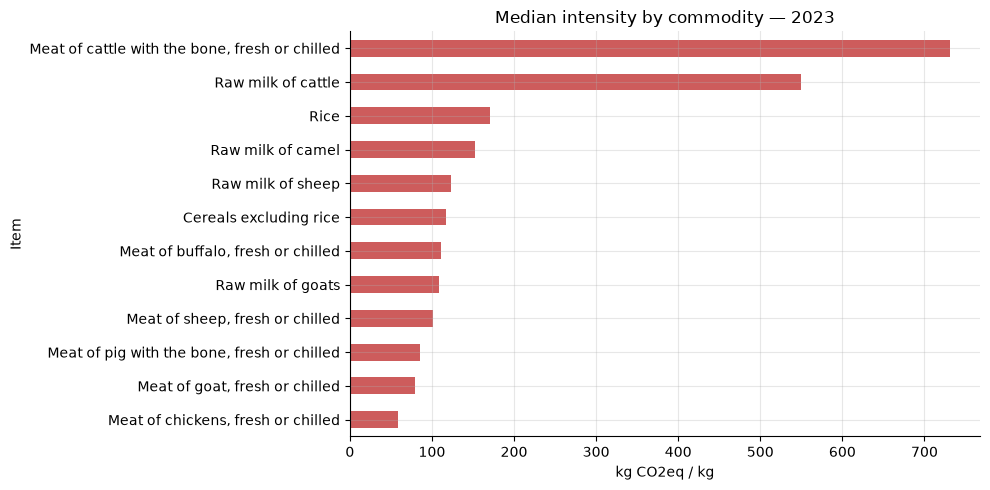

Item
Meat of cattle with the bone, fresh or chilled    731.08000
Raw milk of cattle                                549.72545
Rice                                              170.39340
Raw milk of camel                                 152.33960
Raw milk of sheep                                 123.72595
Cereals excluding rice                            117.45805
Meat of buffalo, fresh or chilled                 111.30280
Raw milk of goats                                 108.99180
Meat of sheep, fresh or chilled                   100.73525
Meat of pig with the bone, fresh or chilled        85.11650
Meat of goat, fresh or chilled                     79.42970
Meat of chickens, fresh or chilled                 58.23950
Name: Value, dtype: float64

In [8]:
comm_int = footprint.commodity_intensity(inten_c, YEAR)
viz.barh_ranking(comm_int, f'Median intensity by commodity — {YEAR}', 'kg CO2eq / kg', color='indianred'); plt.show()
comm_int.head(12)

lever commodity: Meat of cattle with the bone, fresh or chilled


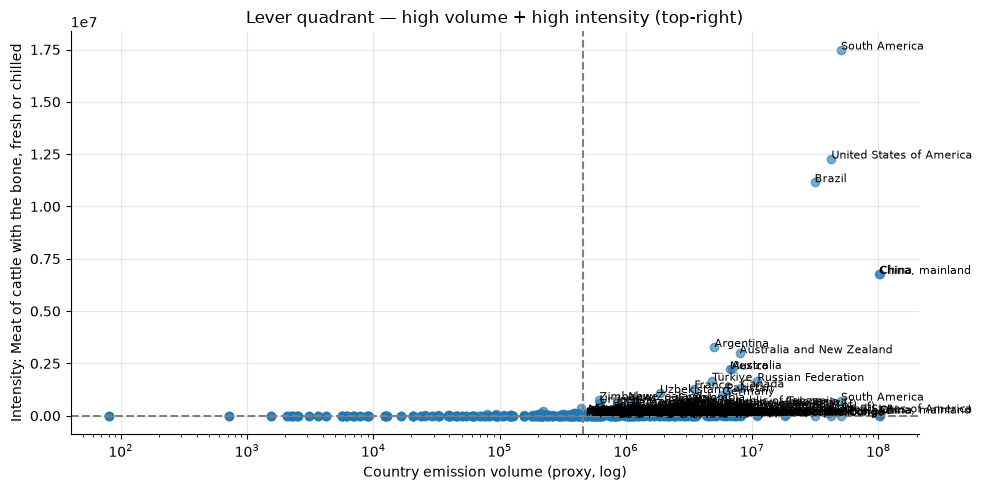

In [9]:
lever_commodity = footprint.pick_lever_commodity(comm_int, inten_c, YEAR)
q = footprint.lever_table(emis_c, inten_c, YEAR, lever_commodity)
print('lever commodity:', lever_commodity)
viz.lever_quadrant(q, lever_commodity); plt.show()

### Emissions per hectare of agricultural land

land item: Agricultural land


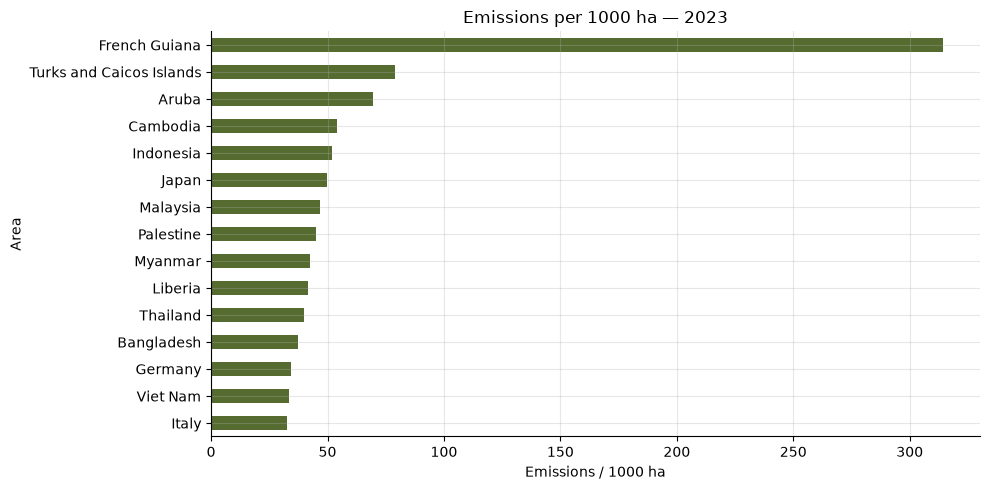

,emissions,land_1000ha,emis_per_1000ha
Area,,,
French Guiana,1.336877e+04,42.514,314.455756
Turks and Caicos Islands,1.618444e+02,2.050,78.948488
Aruba,9.125379e+02,13.110,69.606247
Cambodia,4.178078e+05,7701.090,54.253074
Indonesia,2.938934e+06,56597.490,51.926925
Japan,5.222348e+05,10474.180,49.859257
Malaysia,4.828326e+05,10366.670,46.575480
Palestine,2.059018e+04,456.130,45.141037
Myanmar,6.336198e+05,14953.550,42.372534


In [10]:
per_ha, land_item = footprint.emissions_per_land(emis_c, land_c, YEAR)
print('land item:', land_item)
if per_ha is not None:
    viz.barh_ranking(per_ha['emis_per_1000ha'], f'Emissions per 1000 ha — {YEAR}', 'Emissions / 1000 ha', n=15, color='darkolivegreen'); plt.show()
    display(per_ha.head(15))

## 3 · Strategize (setup) — what's causing more issue & what to pull next

In [11]:
top_source = item_rank.index[0]
top_food = comm_int.index[0]
ds, why = footprint.next_dataset(top_source)
print(f'BY VOLUME   : {top_source} ({100*item_rank.iloc[0]/item_rank.sum():.1f}% of ranked total)')
print(f'BY INTENSITY: {top_food} (most CO2eq per kg)')
print(f'NEXT DATASET: {ds}')
print(f'   why      : {why}')

summary = pd.DataFrame({'finding': {
    'top_source_by_volume': top_source,
    'top_food_by_intensity': top_food,
    'top10_country_share_%': round(100*country_rank.head(10).sum()/country_rank.sum(),1),
    'lever_commodity': lever_commodity,
    'analysis_year': YEAR,
}})
summary

BY VOLUME   : Pre- and post-production (16.7% of ranked total)
BY INTENSITY: Meat of cattle with the bone, fresh or chilled (most CO2eq per kg)
NEXT DATASET: Emissions from pre and post agricultural production (Agrifood systems)
   why      : food processing, transport, retail, waste — supply-chain levers


,finding
top_source_by_volume,Pre- and post-production
top_food_by_intensity,"Meat of cattle with the bone, fresh or chilled"
top10_country_share_%,66.8
lever_commodity,"Meat of cattle with the bone, fresh or chilled"
analysis_year,2023
